**Кластеризация латентных представлений для типизации режимов скважин**

**Цель**: Получить устойчивые кластеры в латентном пространстве автоэнкодера,
интерпретировать каждый кластер как типовой режим работы скважины и сравнить
качество разделения с baseline (EDA этап, Уровни 1–2).

**Входные данные**:
- models/ecn/model.pth   — лучший автоэнкодер ЭЦН (GRU, latent_dim=32)
- models/shgn/model.pth  — лучший автоэнкодер ШГН (Hybrid, latent_dim=8)
- data/processed/ecn_*.csv        — нормализованные временные ряды ЭЦН
- data/processed/shgn_*.csv       — нормализованные временные ряды ШГН

**Этапы**:
1. Загрузка моделей и данных
2. Кодирование всего датасета → матрица латентных векторов
3. Подбор числа кластеров (Elbow + Silhouette)
4. K-Means кластеризация + сохранение центроидов
5. Оценка качества: Silhouette, Davies-Bouldin, Calinski-Harabasz
6. Визуализация латентного пространства (PCA-2D / UMAP)
7. Интерпретация кластеров: декодирование центроидов → типовые профили
8. Сохранение артефактов кластеризации

**Выходные данные**:
- models/ecn/ecn_kmeans.pkl   — K-Means модель ЭЦН
- models/shgn/shgn_kmeans.pkl  — K-Means модель ШГН
- models/ecn/ecn_labels.npy   — метки кластеров для всех окон ЭЦН
- models/shgn/shgn_labels.npy  — метки кластеров для всех окон ШГН
- models/ecn/ecn_latents.npy  — латентные векторы ЭЦН
- models/shgn/shgn_latents.npy — латентные векторы ШГН

In [5]:
# %%
import logging
import pickle
import sys
import warnings
from pathlib import Path
from typing import Any, Protocol

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
from torchinfo import summary
from umap import UMAP

sys.path.insert(0, str(Path("../models").resolve()))
from models import build_model

# ==== 1. ЗАГРУЗКА МОДЕЛЕЙ И ДАННЫХ ====

In [6]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Устройство: %s", DEVICE)

2026-02-24 21:53:39,534 - INFO - Устройство: cuda


In [7]:
COLORS: dict[str, str] = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
}
CLUSTER_PALETTE: list[str] = [
    "#2E86AB",
    "#A23B72",
    "#F18F01",
    "#C73E1D",
    "#4CAF50",
    "#9C27B0",
]

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

FEATURE_COLUMNS: list[str] = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]
WINDOW_SIZES: dict[str, int] = {"ecn": 120, "shgn": 100}
STRIDES: dict[str, int] = {"ecn": 20, "shgn": 15}
N_CLUSTERS: dict[str, int] = {"ecn": 3, "shgn": 4}

MODEL_HYPERPARAMS: dict[str, Any] = {
    "input_dim": len(FEATURE_COLUMNS),
    "hidden_size": 192,
    "num_layers": 2,
    "kernel_size": 5,
    "dilation_base": 2,
    "dropout": 0.15,
}

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

In [8]:
def _windows_from_array(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(X) < window_size:
        return np.empty((0, window_size, X.shape[1]), dtype=np.float32)
    w = sliding_window_view(X, window_shape=window_size, axis=0)[::stride]
    return np.transpose(w, (0, 2, 1)).astype(np.float32)

In [9]:
def load_windows(prefix: str) -> tuple[np.ndarray, StandardScaler]:
    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler: StandardScaler = pickle.load(f)

    window_size = WINDOW_SIZES[prefix]
    stride = STRIDES[prefix]

    parts = [
        _windows_from_array(
            np.load(DATA_DIR / f"X_{prefix}_{split}.npy").astype(np.float32),
            window_size,
            stride,
        )
        for split in ("train", "val", "test")
    ]
    X = np.concatenate([p for p in parts if len(p) > 0])
    logger.info("%s: всего окон=%d | shape=%s", prefix.upper(), X.shape[0], X.shape)
    return X, scaler

In [10]:
X_ecn, scaler_ecn = load_windows("ecn")
X_shgn, scaler_shgn = load_windows("shgn")

2026-02-24 21:54:04,038 - INFO - ECN: всего окон=2052 | shape=(2052, 120, 9)


2026-02-24 21:54:04,076 - INFO - SHGN: всего окон=8343 | shape=(8343, 100, 9)


# ==== 2. ЗАГРУЗКА ВЕСОВ И КОДИРОВАНИЕ ====

In [16]:
class Encodable(Protocol):
    def encode(self, x: torch.Tensor) -> torch.Tensor: ...

In [11]:
def load_model(prefix: str) -> tuple[nn.Module, dict[str, Any]]:
    checkpoint: dict[str, Any] = torch.load(
        MODELS_DIR / prefix / "model.pth",
        map_location=DEVICE,
        weights_only=False,
    )
    hp = MODEL_HYPERPARAMS
    model = build_model(
        arch_name=checkpoint["architecture"],
        input_dim=hp["input_dim"],
        hidden_size=hp["hidden_size"],
        latent_dim=checkpoint["latent_dim"],
        num_layers=hp["num_layers"],
        kernel_size=hp["kernel_size"],
        dilation_base=hp["dilation_base"],
        dropout=hp["dropout"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    logger.info(
        "%s: arch=%s | latent_dim=%s | metrics=%s",
        prefix.upper(),
        checkpoint["architecture"],
        checkpoint["latent_dim"],
        checkpoint["metrics"],
    )
    return model, checkpoint

In [12]:
model_ecn, ckpt_ecn = load_model("ecn")
model_shgn, ckpt_shgn = load_model("shgn")

2026-02-24 21:54:18,160 - INFO - ECN: arch=GRU | latent_dim=32 | metrics={'val_loss': 0.11795883866426704, 'val_mae': 0.06856070910869677, 'test_loss': 0.12046007841032323, 'test_mae': 0.08296228105336041}
2026-02-24 21:54:18,181 - INFO - SHGN: arch=Hybrid | latent_dim=8 | metrics={'val_loss': 0.3844532113808852, 'val_mae': 0.5290358506716215, 'test_loss': 0.43648395553613323, 'test_mae': 0.5832279706612612}


In [13]:
for prefix, model, window_size in (
    ("ЭЦН", model_ecn, WINDOW_SIZES["ecn"]),
    ("ШГН", model_shgn, WINDOW_SIZES["shgn"]),
):
    model_summary = summary(
        model,
        input_size=(1, window_size, len(FEATURE_COLUMNS)),
        col_names=["input_size", "output_size", "num_params"],
        depth=3,
        verbose=0,
    )
    logger.info("\n%s:\n%s", prefix, model_summary)

2026-02-24 21:54:24,923 - INFO - 
ЭЦН:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
GRUAutoencoder                           [1, 120, 9]               [1, 120, 9]               --
├─GRU: 1-1                               [1, 120, 9]               [1, 120, 384]             899,712
├─AttentionPool: 1-2                     [1, 120, 384]             [1, 384]                  --
│    └─Linear: 2-1                       [1, 120, 384]             [1, 120, 1]               385
├─Linear: 1-3                            [1, 384]                  [1, 32]                   12,320
├─Linear: 1-4                            [1, 32]                   [1, 384]                  12,672
├─GRU: 1-5                               [1, 120, 9]               [1, 120, 192]             339,264
├─Linear: 1-6                            [1, 120, 192]             [1, 120, 9]               1,737
Total params: 1,266,090
Trainable params: 1,266,090
Non-trainable para

In [17]:
def encode_dataset(model: Encodable, X: np.ndarray, batch_size: int = 512) -> np.ndarray:
    latents: list[np.ndarray] = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.from_numpy(X[start : start + batch_size]).float().to(DEVICE)
            z = model.encode(batch)
            latents.append(z.cpu().numpy())
    return np.concatenate(latents)

In [18]:
Z_ecn = encode_dataset(model_ecn, X_ecn)
Z_shgn = encode_dataset(model_shgn, X_shgn)
logger.info("ЭЦН латенты: %s | ШГН латенты: %s", Z_ecn.shape, Z_shgn.shape)

2026-02-24 21:54:53,341 - INFO - ЭЦН латенты: (2052, 32) | ШГН латенты: (8343, 8)


# ==== 3. ПОДБОР ЧИСЛА КЛАСТЕРОВ ====

In [19]:
def plot_elbow_silhouette(Z: np.ndarray, pump_type: str, k_range: range = range(2, 9)) -> int:
    inertias: list[float] = []
    silhouettes: list[float] = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(Z)
        inertias.append(float(km.inertia_))
        silhouettes.append(float(silhouette_score(Z, labels, sample_size=min(5000, len(Z)), random_state=SEED)))

    k_list = list(k_range)
    best_k = k_list[int(np.argmax(silhouettes))]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(k_list, inertias, marker="o", color=COLORS["primary"], linewidth=2)
    ax1.set_title("Elbow (инерция)")
    ax1.set_xlabel("Число кластеров k")
    ax1.set_ylabel("Inertia")

    ax2.plot(k_list, silhouettes, marker="o", color=COLORS["secondary"], linewidth=2)
    ax2.axvline(x=best_k, color=COLORS["accent"], linestyle="--", linewidth=1.5, label=f"best k={best_k}")
    ax2.set_title("Silhouette Score")
    ax2.set_xlabel("Число кластеров k")
    ax2.set_ylabel("Silhouette")
    ax2.legend()

    fig.suptitle(f"{pump_type}: подбор числа кластеров", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    logger.info("%s: лучший k по Silhouette = %d (%.4f)", pump_type, best_k, max(silhouettes))
    return best_k

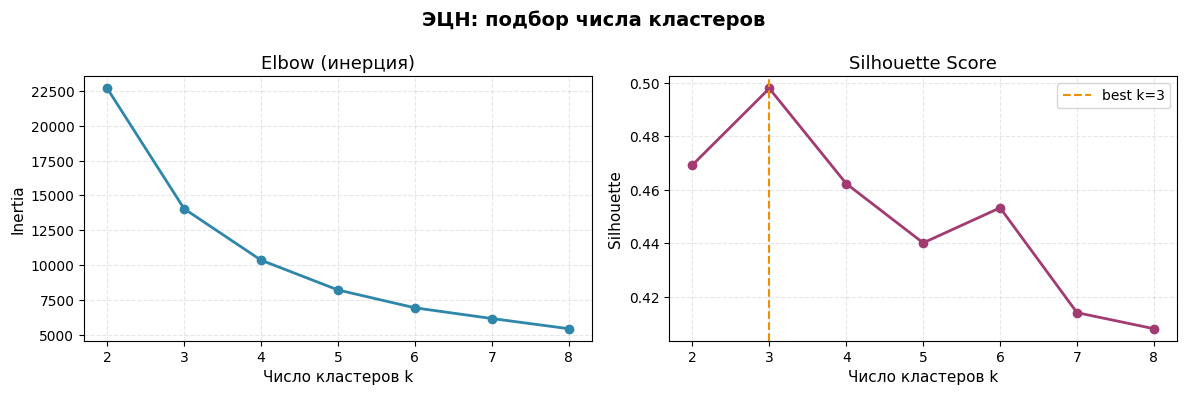

2026-02-24 21:55:12,381 - INFO - ЭЦН: лучший k по Silhouette = 3 (0.4978)


In [20]:
N_CLUSTERS["ecn"] = plot_elbow_silhouette(Z_ecn, "ЭЦН")

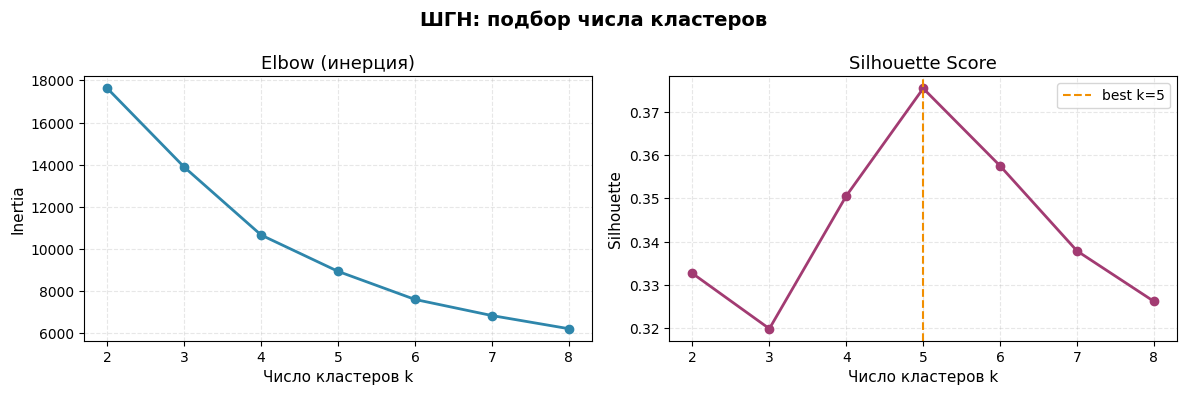

2026-02-24 21:55:26,767 - INFO - ШГН: лучший k по Silhouette = 5 (0.3756)


In [21]:
N_CLUSTERS["shgn"] = plot_elbow_silhouette(Z_shgn, "ШГН")

# ==== 4. K-MEANS КЛАСТЕРИЗАЦИЯ ====

In [22]:
def fit_kmeans(Z: np.ndarray, n_clusters: int, pump_type: str) -> tuple[KMeans, np.ndarray]:
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20)
    labels = km.fit_predict(Z)

    sil = silhouette_score(Z, labels, sample_size=min(5000, len(Z)), random_state=SEED)
    db = davies_bouldin_score(Z, labels)
    ch = calinski_harabasz_score(Z, labels)

    logger.info(
        "%s | k=%d | Silhouette=%.4f | Davies-Bouldin=%.4f | Calinski-Harabasz=%.1f",
        pump_type,
        n_clusters,
        sil,
        db,
        ch,
    )
    return km, labels

In [23]:
km_ecn, labels_ecn = fit_kmeans(Z_ecn, N_CLUSTERS["ecn"], "ЭЦН")
km_shgn, labels_shgn = fit_kmeans(Z_shgn, N_CLUSTERS["shgn"], "ШГН")

2026-02-24 21:55:40,145 - INFO - ЭЦН | k=3 | Silhouette=0.4978 | Davies-Bouldin=0.7364 | Calinski-Harabasz=2298.6
2026-02-24 21:55:40,522 - INFO - ШГН | k=5 | Silhouette=0.3756 | Davies-Bouldin=0.9580 | Calinski-Harabasz=4497.1


# ==== 4.5. ПОРОГИ ОТКЛОНЕНИЙ ПО КЛАСТЕРАМ ====

In [24]:
def compute_deviations(Z: np.ndarray, km: KMeans, labels: np.ndarray) -> np.ndarray:
    deviations = np.zeros(len(Z), dtype=np.float64)
    for k in range(len(km.cluster_centers_)):
        mask = labels == k
        center = km.cluster_centers_[k]
        deviations[mask] = np.linalg.norm(Z[mask] - center, axis=1)
    return deviations

In [25]:
def compute_thresholds(
    deviations: np.ndarray,
    labels: np.ndarray,
    n_clusters: int,
    warn_percentile: float = 95.0,
    alert_percentile: float = 99.0,
) -> dict[int, dict[str, float]]:
    thresholds: dict[int, dict[str, float]] = {}
    for k in range(n_clusters):
        cluster_devs = deviations[labels == k]
        thresholds[k] = {
            "warn": float(np.percentile(cluster_devs, warn_percentile)),
            "alert": float(np.percentile(cluster_devs, alert_percentile)),
            "mean": float(cluster_devs.mean()),
            "std": float(cluster_devs.std()),
            "p50": float(np.percentile(cluster_devs, 50)),
        }
    return thresholds

In [26]:
def plot_deviation_histograms(
    deviations: np.ndarray,
    labels: np.ndarray,
    thresholds: dict[int, dict[str, float]],
    pump_type: str,
    n_clusters: int,
) -> None:
    fig, axes = plt.subplots(1, n_clusters, figsize=(5 * n_clusters, 4), sharey=False)
    axes_flat: list[plt.Axes] = axes.tolist() if n_clusters > 1 else [axes]

    for k, ax in enumerate(axes_flat):
        cluster_devs = deviations[labels == k]
        color = CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)]

        ax.hist(cluster_devs, bins=60, color=color, alpha=0.7, edgecolor="none")
        ax.axvline(
            thresholds[k]["warn"],
            color="#f39c12",
            linewidth=2,
            linestyle="--",
            label=f"Warn p95={thresholds[k]['warn']:.3f}",
        )
        ax.axvline(
            thresholds[k]["alert"],
            color="#e74c3c",
            linewidth=2,
            linestyle="--",
            label=f"Alert p99={thresholds[k]['alert']:.3f}",
        )
        ax.set_title(f"Кластер {k} (n={int((labels == k).sum())})")
        ax.set_xlabel("Deviation (L2 до центроида)")
        ax.set_ylabel("Число окон")
        ax.legend(fontsize=9)

    fig.suptitle(f"{pump_type}: распределение отклонений по кластерам", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

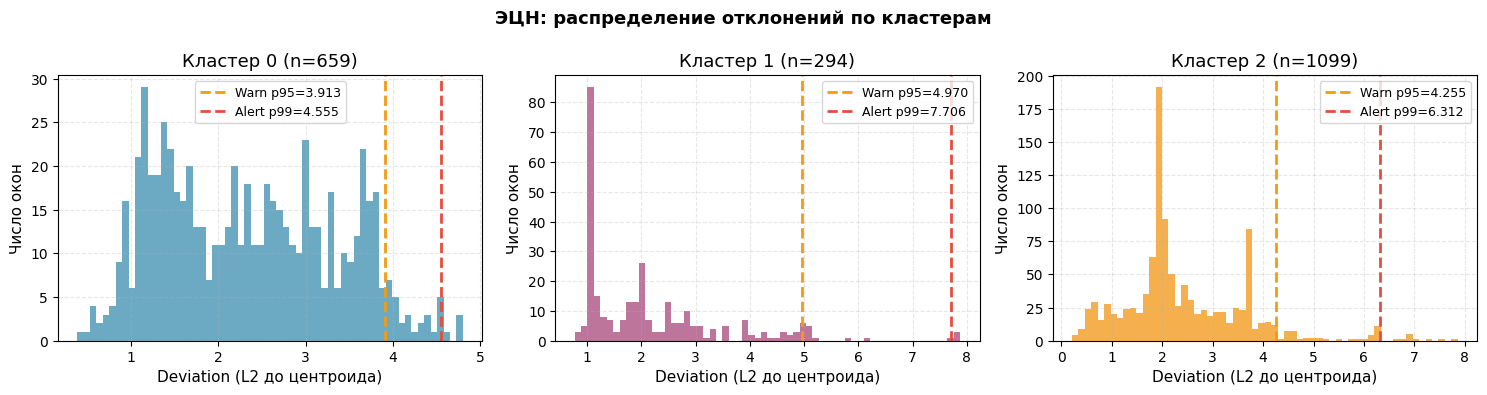

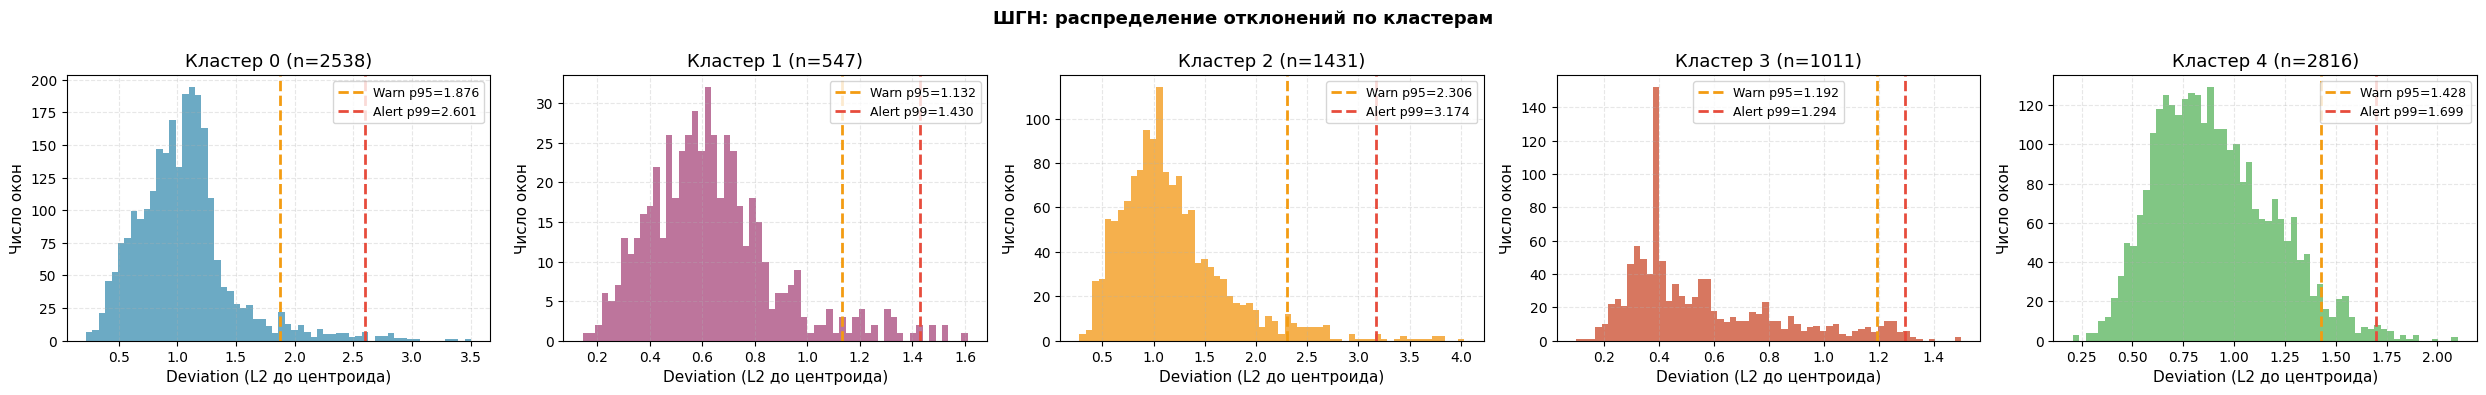

2026-02-24 21:56:48,043 - INFO - ЭЦН пороги:
2026-02-24 21:56:48,044 - INFO -   Кластер 0 | warn=3.9125 | alert=4.5549 | mean=2.3352 | std=0.9991
2026-02-24 21:56:48,044 - INFO -   Кластер 1 | warn=4.9701 | alert=7.7061 | mean=2.1827 | std=1.3550
2026-02-24 21:56:48,045 - INFO -   Кластер 2 | warn=4.2553 | alert=6.3122 | mean=2.3916 | std=1.1944
2026-02-24 21:56:48,046 - INFO - ШГН пороги:
2026-02-24 21:56:48,046 - INFO -   Кластер 0 | warn=1.8755 | alert=2.6012 | mean=1.0564 | std=0.4194
2026-02-24 21:56:48,049 - INFO -   Кластер 1 | warn=1.1319 | alert=1.4299 | mean=0.6352 | std=0.2445
2026-02-24 21:56:48,050 - INFO -   Кластер 2 | warn=2.3063 | alert=3.1742 | mean=1.1878 | std=0.5437
2026-02-24 21:56:48,051 - INFO -   Кластер 3 | warn=1.1923 | alert=1.2945 | mean=0.5543 | std=0.2804
2026-02-24 21:56:48,053 - INFO -   Кластер 4 | warn=1.4280 | alert=1.6993 | mean=0.9072 | std=0.2905


In [27]:
devs_ecn = compute_deviations(Z_ecn, km_ecn, labels_ecn)
devs_shgn = compute_deviations(Z_shgn, km_shgn, labels_shgn)

thresholds_ecn = compute_thresholds(devs_ecn, labels_ecn, N_CLUSTERS["ecn"])
thresholds_shgn = compute_thresholds(devs_shgn, labels_shgn, N_CLUSTERS["shgn"])

plot_deviation_histograms(devs_ecn, labels_ecn, thresholds_ecn, "ЭЦН", N_CLUSTERS["ecn"])
plot_deviation_histograms(devs_shgn, labels_shgn, thresholds_shgn, "ШГН", N_CLUSTERS["shgn"])

for pump_type, thr in (("ЭЦН", thresholds_ecn), ("ШГН", thresholds_shgn)):
    logger.info("%s пороги:", pump_type)
    for k, vals in thr.items():
        logger.info(
            "  Кластер %d | warn=%.4f | alert=%.4f | mean=%.4f | std=%.4f",
            k,
            vals["warn"],
            vals["alert"],
            vals["mean"],
            vals["std"],
        )

# ==== 5. ВИЗУАЛИЗАЦИЯ ЛАТЕНТНОГО ПРОСТРАНСТВА ====

In [28]:
def _reduce_to_2d(Z: np.ndarray, method: str) -> tuple[np.ndarray, str]:
    if method == "PCA":
        reducer = PCA(n_components=2, random_state=SEED)
        Z_2d = np.asarray(reducer.fit_transform(Z))
        explained = float(reducer.explained_variance_ratio_.sum())
        return Z_2d, f"PCA (объяснённая дисперсия: {explained:.1%})"

    reducer_umap = UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        Z_2d = np.asarray(reducer_umap.fit_transform(Z))
    return Z_2d, "UMAP"


def plot_latent_space(
    Z: np.ndarray,
    labels: np.ndarray,
    pump_type: str,
    method: str = "PCA",
) -> None:
    Z_2d, subtitle = _reduce_to_2d(Z, method)
    unique_labels = np.unique(labels)

    fig, ax = plt.subplots(figsize=(10, 7))
    for k in unique_labels:
        mask = labels == k
        ax.scatter(
            Z_2d[mask, 0],
            Z_2d[mask, 1],
            c=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)],
            label=f"Кластер {k} (n={int(mask.sum())})",
            alpha=0.5,
            s=8,
            rasterized=True,
        )

    ax.set_title(f"{pump_type}: латентное пространство — {subtitle}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Компонента 1")
    ax.set_ylabel("Компонента 2")
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

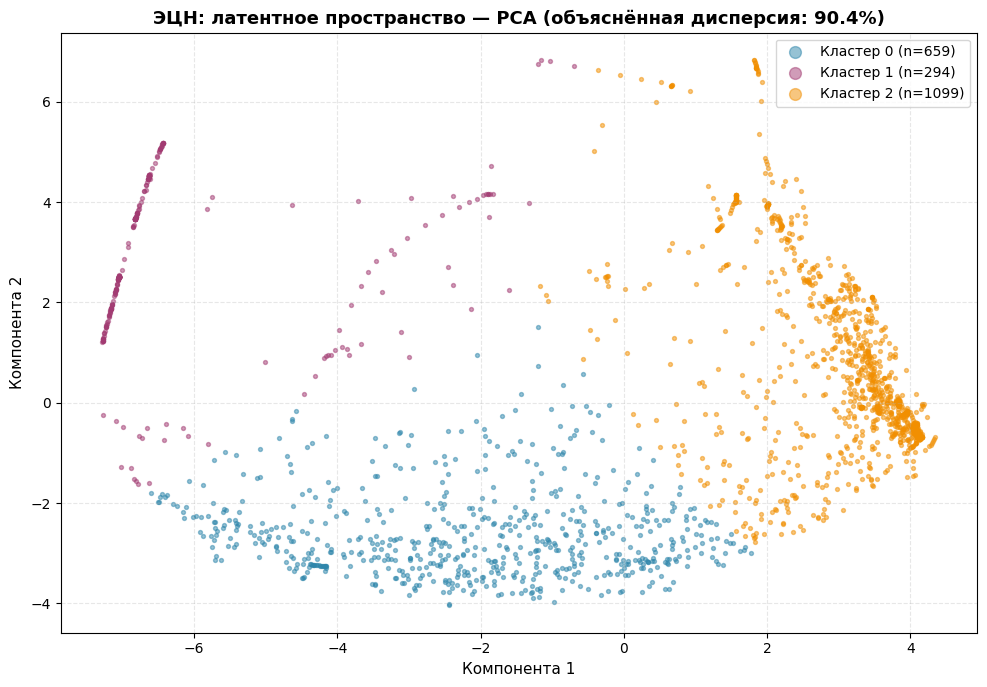

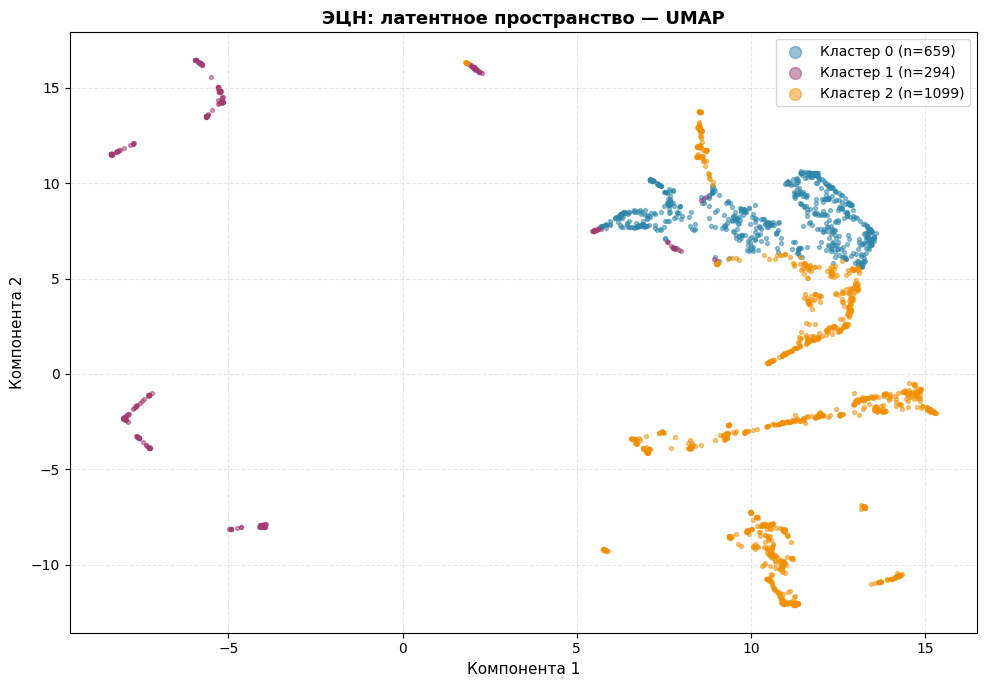

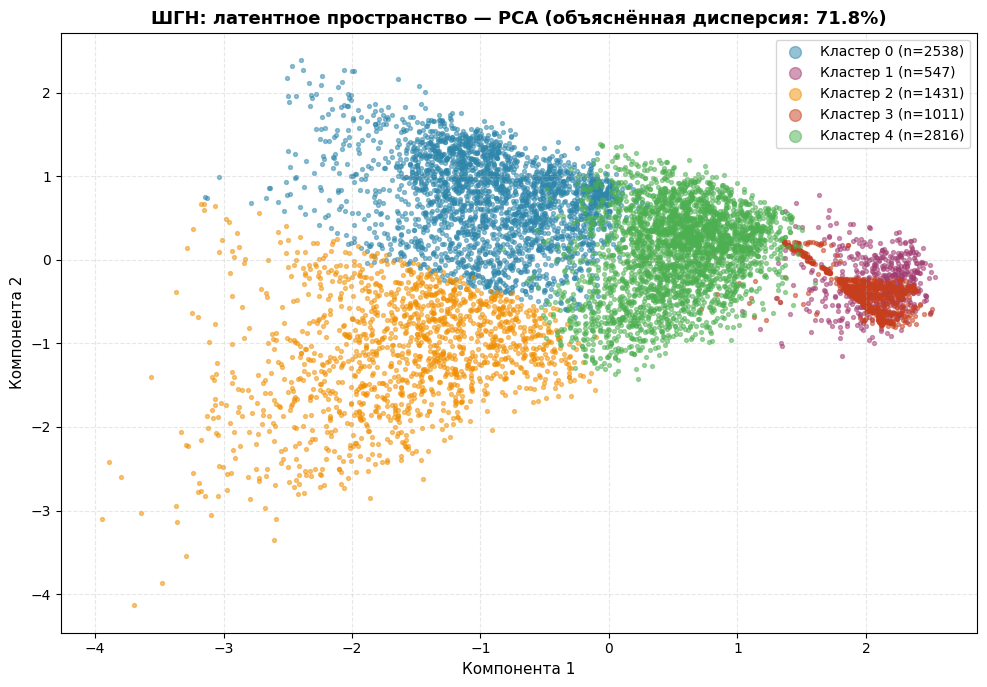

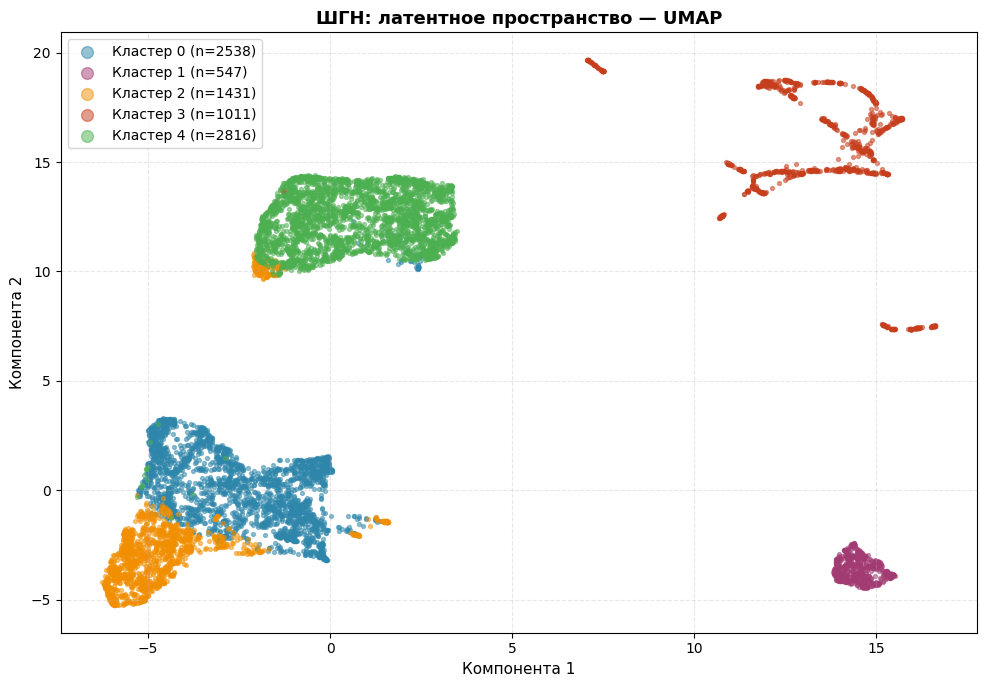

In [29]:
for pump_type, Z, labels in (("ЭЦН", Z_ecn, labels_ecn), ("ШГН", Z_shgn, labels_shgn)):
    for method in ("PCA", "UMAP"):
        plot_latent_space(Z, labels, pump_type, method)

# ==== 6. ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ ====

In [30]:
def decode_centroid_by_nearest(
    Z: np.ndarray,
    X: np.ndarray,
    centroid: np.ndarray,
    n_neighbors: int = 50,
) -> np.ndarray:
    dists = np.linalg.norm(Z - centroid, axis=1)
    nearest_idx = np.argsort(dists)[:n_neighbors]
    return X[nearest_idx].mean(axis=0)

In [34]:
def plot_cluster_profiles(
    Z: np.ndarray,
    X: np.ndarray,
    km: KMeans,
    pump_type: str,
    n_clusters: int,
    n_neighbors: int = 50,
) -> None:
    steps = np.arange(X.shape[1])
    fig, axes = plt.subplots(n_clusters, len(FEATURE_COLUMNS), figsize=(22, 3 * n_clusters))

    for k in range(n_clusters):
        profile = decode_centroid_by_nearest(Z, X, km.cluster_centers_[k], n_neighbors)
        row_axes: list[plt.Axes] = axes[k].tolist() if n_clusters > 1 else axes.tolist()

        for j, feature in enumerate(FEATURE_COLUMNS):
            ax = row_axes[j]
            ax.plot(steps, profile[:, j], color=CLUSTER_PALETTE[k % len(CLUSTER_PALETTE)], linewidth=1.5)
            if k == 0:
                ax.set_title(feature, fontsize=9, fontweight="bold")
            if j == 0:
                ax.set_ylabel(f"Кластер {k}", fontsize=9)

    fig.suptitle(f"{pump_type}: типовые профили кластеров", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

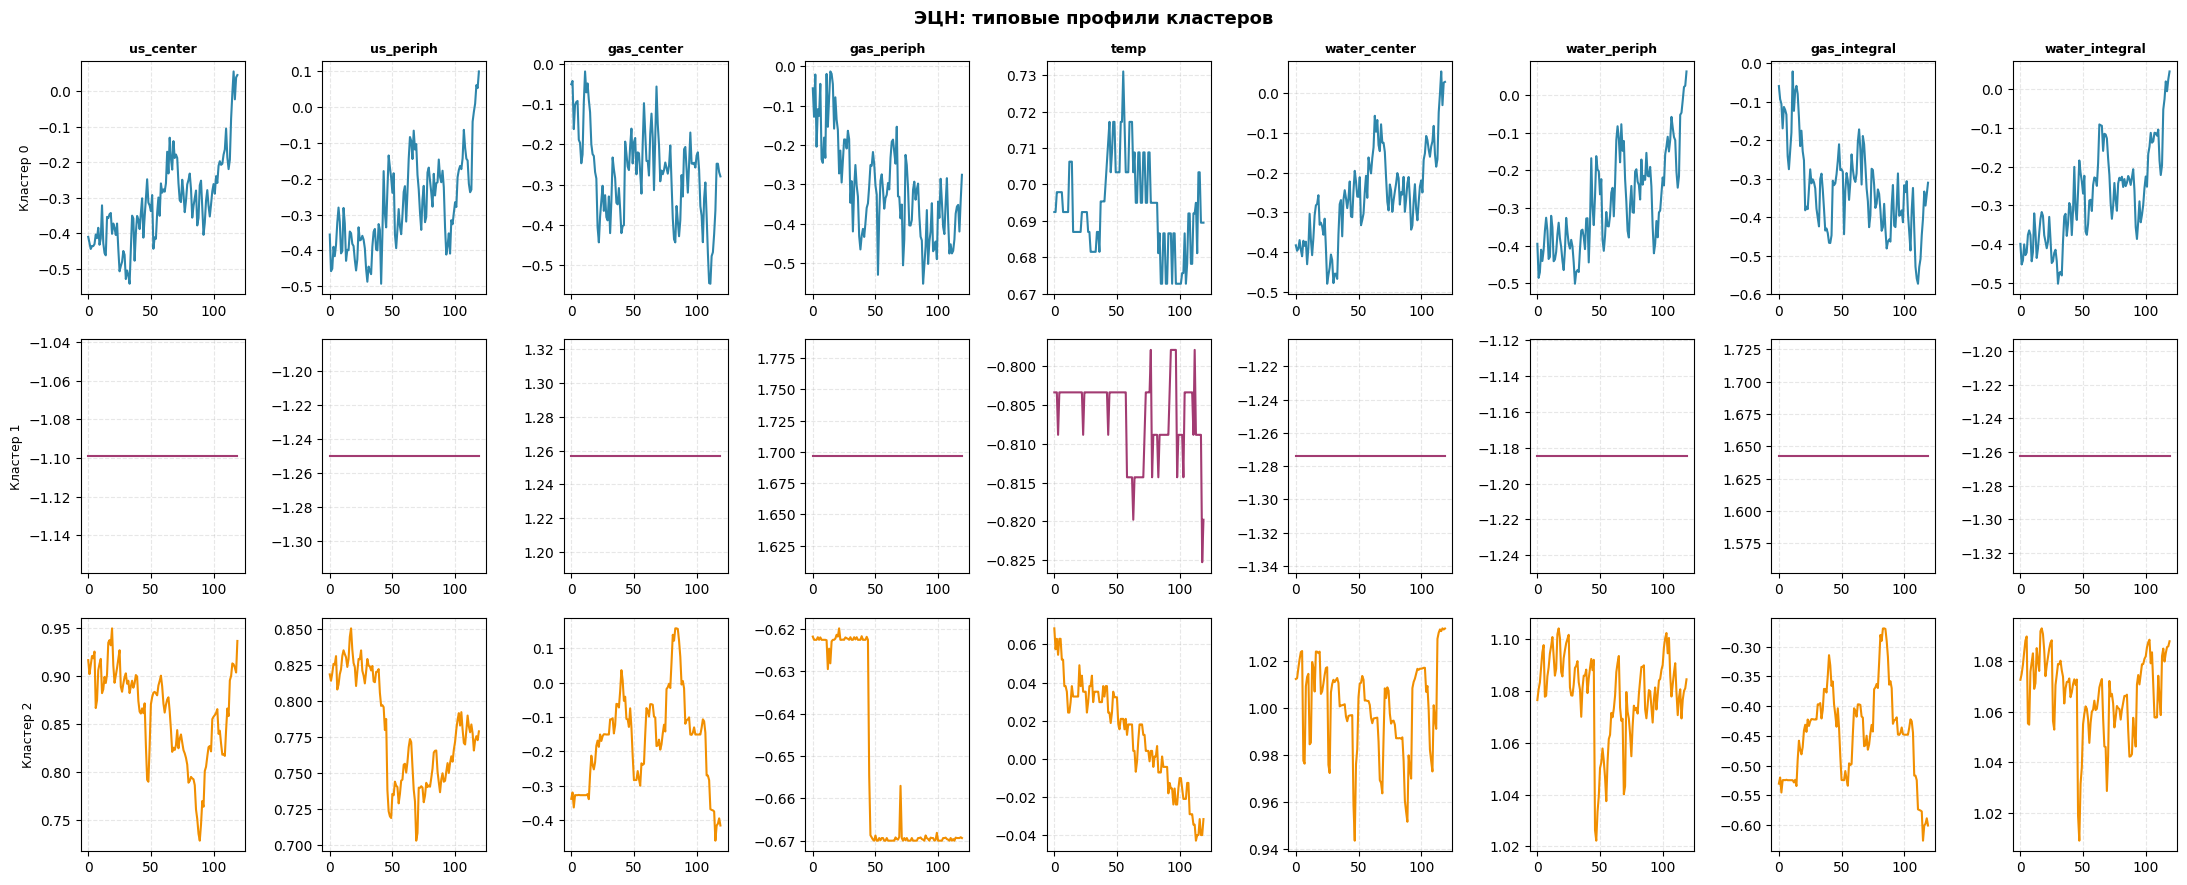

In [35]:
plot_cluster_profiles(Z_ecn, X_ecn, km_ecn, "ЭЦН", N_CLUSTERS["ecn"])

| Кластер | Состояние         | Обоснование                                                                                                                                                                                               |
| ------- | ----------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Стабильная работа | УЗ максимальный (+0.86), обводнённость максимальная (+1.00, +1.08), газ минимальный (−0.65). Std малый (~0.02–0.05) — режим устойчивый, насос штатно гонит жидкость                                       |
| 1       | Выключена         | Абсолютная константа по всем параметрам (Std=0). УЗ минимальный (−1.10, −1.25), газосодержание максимальное (+1.26, +1.70) — труба заполнена газом, жидкость не движется. Температура минимальная (−0.81) |
| 2       | Запуск            | Температура высокая (+0.69), УЗ и обводнённость отрицательные но нарастают к концу окна — насос разгоняется. Std ~0.12 — параметры в движении, режим ещё не вышел на рабочий уровень                      |

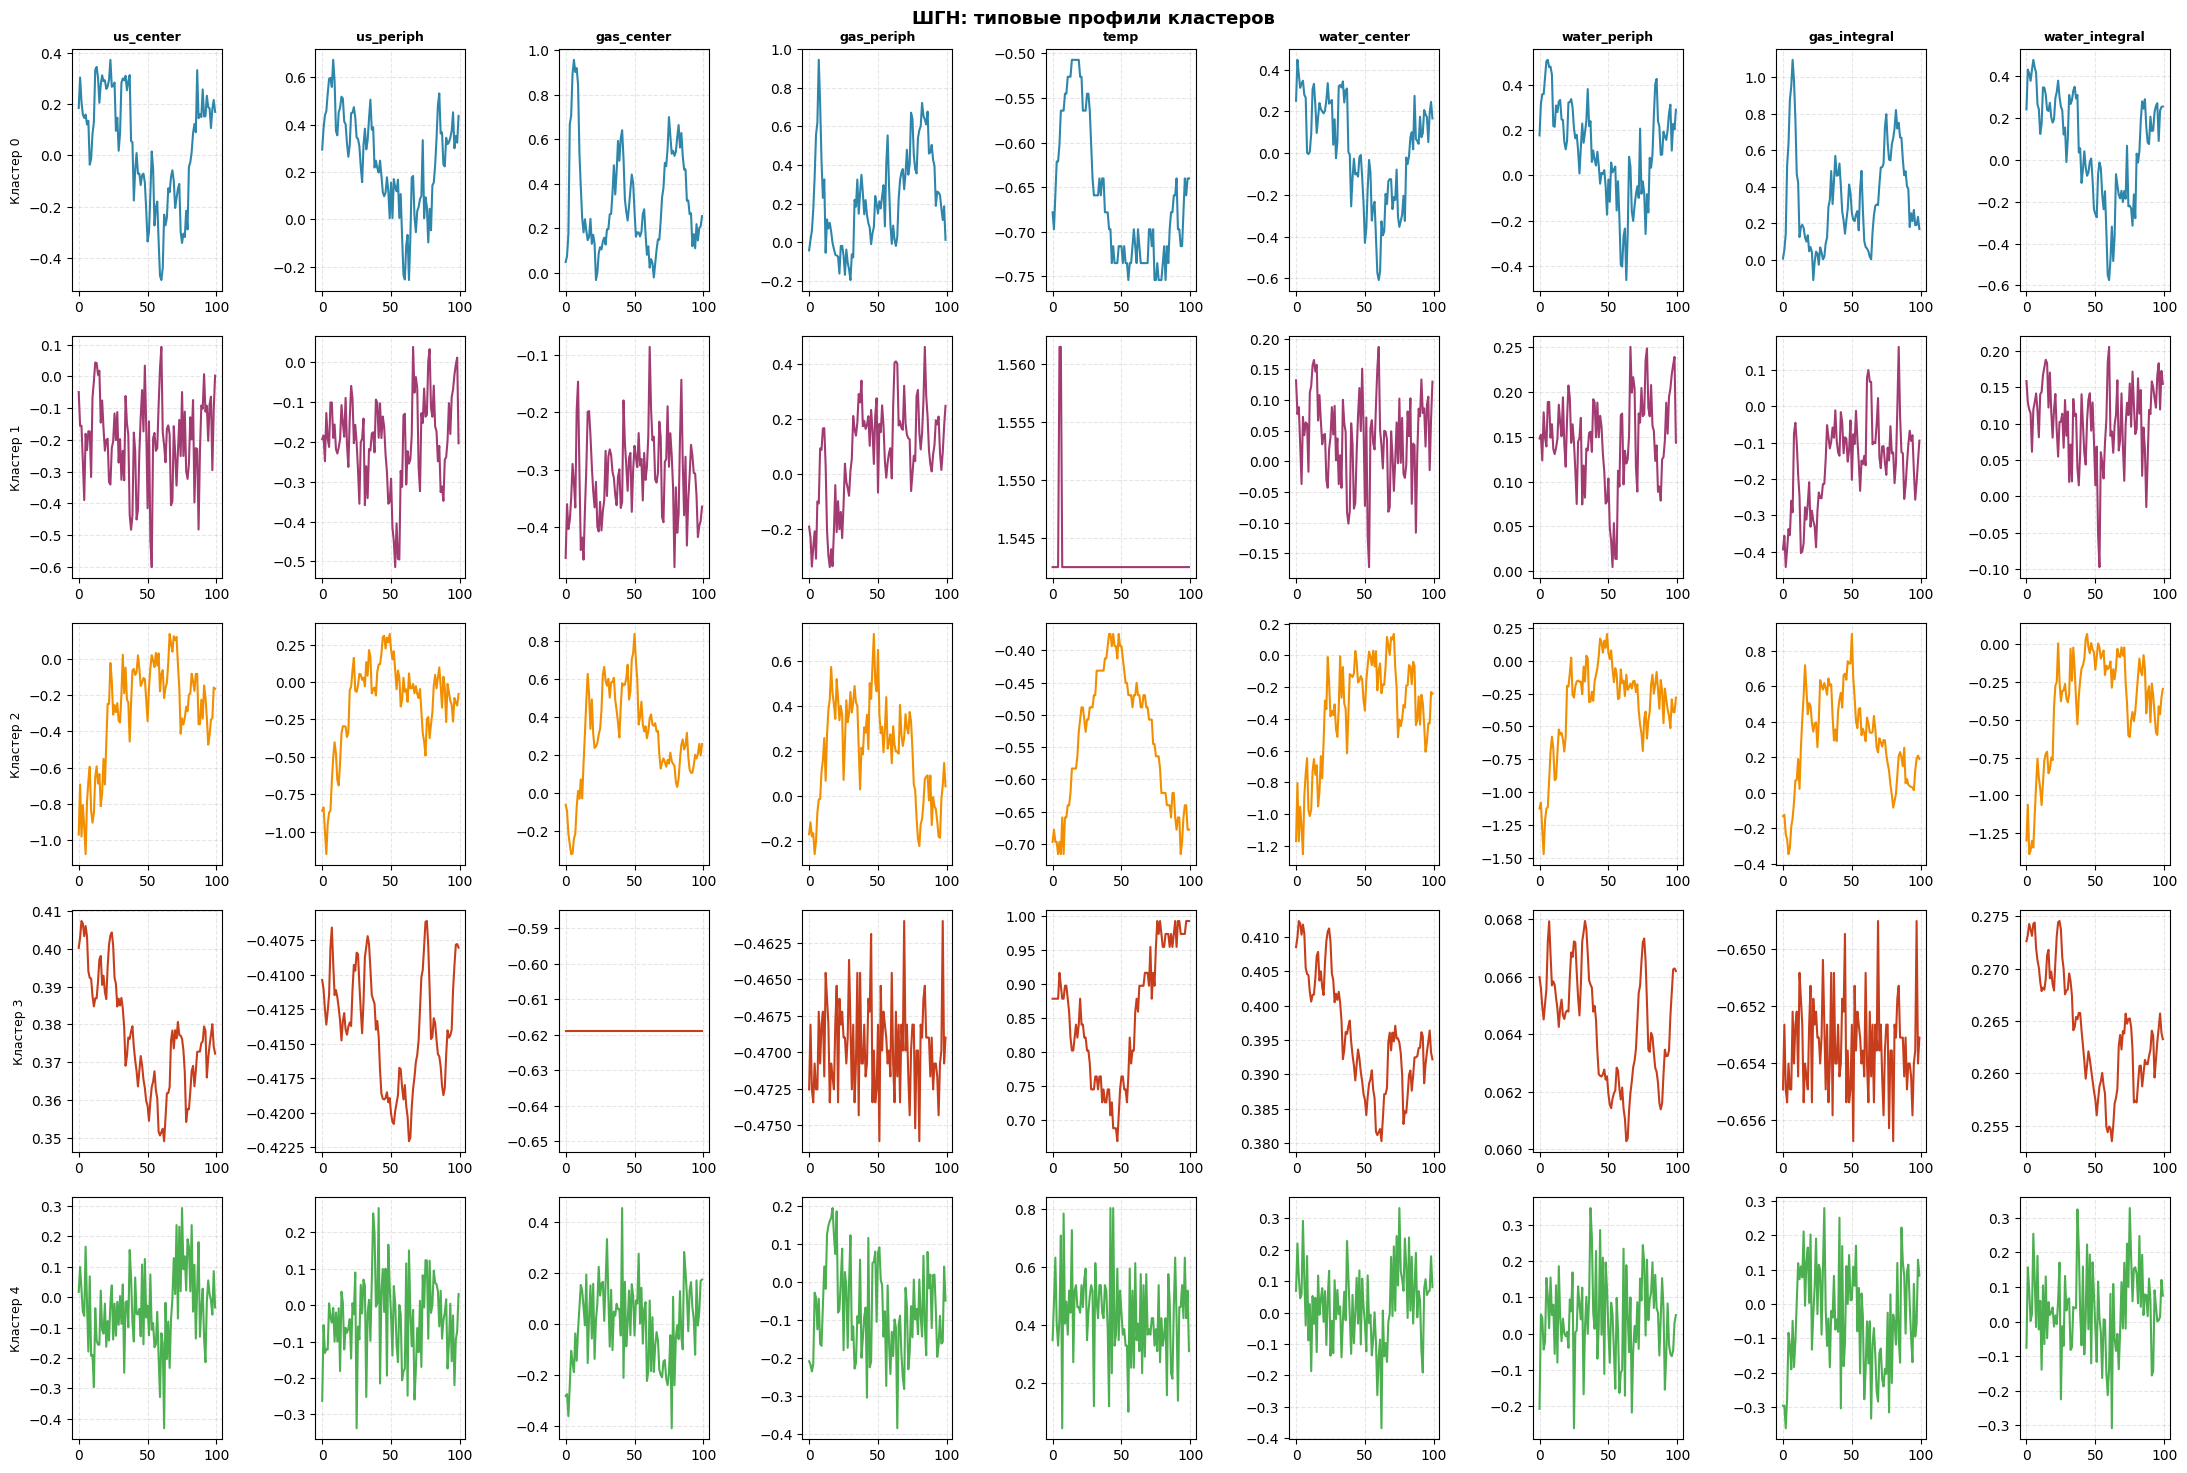

In [36]:
plot_cluster_profiles(Z_shgn, X_shgn, km_shgn, "ШГН", N_CLUSTERS["shgn"])

| Кластер | Состояние                         | Обоснование                                                                                                                                                                       |
| ------- | --------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 0       | Фаза газа                         | Температура низкая (−0.66), газосодержание положительное (+0.32), обводнённость ~0. Высокий Std (~0.22–0.26) — параметры нестабильны, труба содержит газожидкостную смесь         |
| 1       | Фаза воды                        | Температура аномально максимальная (+1.54, Std≈0) — стабильный тепловой режим. Газ отрицательный (−0.31), обводнённость небольшая. Возможна фаза горячей воды или тепловой застой |
| 2       | Переход газ→жидкость             | Обводнённость отрицательная (−0.35), газ положительный (+0.29), температура низкая (−0.54), Std максимальный (~0.30–0.36). Широкое облако на PCA — фаза смены газ→жидкость        |
| 3       | Фаза нефти                       | Газ минимальный (−0.62, Std=0), обводнённость положительная (+0.40), температура высокая (+0.85), Std≈0 — полная стабильность. Насос штатно качает жидкость                       |
| 4       | Переход нефть→вода               | Все параметры ~0, температура умеренная (+0.43), Std~0.12 — насос работает в среднем диапазоне. На PCA плавно граничит с кластером 3                                              |

# ==== 7. СТАТИСТИКА КЛАСТЕРОВ ====

In [37]:
def print_cluster_profiles_stats(
    Z: np.ndarray,
    X: np.ndarray,
    km: KMeans,
    pump_type: str,
    n_neighbors: int = 50,
) -> None:
    rows: list[dict[str, Any]] = []
    for k in range(len(km.cluster_centers_)):
        profile = decode_centroid_by_nearest(Z, X, km.cluster_centers_[k], n_neighbors)
        for j, feature in enumerate(FEATURE_COLUMNS):
            col = profile[:, j]
            rows.append(
                {
                    "Кластер": k,
                    "Параметр": feature,
                    "Среднее": round(float(col.mean()), 4),
                    "Std": round(float(col.std()), 4),
                    "Min": round(float(col.min()), 4),
                    "Max": round(float(col.max()), 4),
                }
            )

    df = pd.DataFrame(rows)
    for k in range(len(km.cluster_centers_)):
        subset = df[df["Кластер"] == k][["Параметр", "Среднее", "Std", "Min", "Max"]]
        logger.info("\n%s | Кластер %d:\n%s", pump_type, k, subset.to_string(index=False))

In [38]:
print_cluster_profiles_stats(Z_ecn, X_ecn, km_ecn, "ЭЦН")

2026-02-24 21:58:54,698 - INFO - 
ЭЦН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center  -0.3136 0.1191 -0.5419  0.0551
     us_periph  -0.2757 0.1250 -0.4933  0.0994
    gas_center  -0.2697 0.1091 -0.5466 -0.0182
    gas_periph  -0.3060 0.1244 -0.5520 -0.0133
          temp   0.6938 0.0125  0.6727  0.7310
  water_center  -0.2561 0.1143 -0.4793  0.0539
  water_periph  -0.2848 0.1262 -0.5008  0.0623
  gas_integral  -0.3214 0.1133 -0.5728 -0.0214
water_integral  -0.2777 0.1197 -0.5024  0.0462
2026-02-24 21:58:54,702 - INFO - 
ЭЦН | Кластер 1:
      Параметр  Среднее   Std     Min     Max
     us_center  -1.0990 0.000 -1.0990 -1.0990
     us_periph  -1.2500 0.000 -1.2500 -1.2500
    gas_center   1.2568 0.000  1.2568  1.2568
    gas_periph   1.6967 0.000  1.6967  1.6967
          temp  -0.8063 0.005 -0.8252 -0.7979
  water_center  -1.2739 0.000 -1.2739 -1.2739
  water_periph  -1.1847 0.000 -1.1847 -1.1847
  gas_integral   1.6426 0.000  1.6426  1.6426
water_integral

In [39]:
print_cluster_profiles_stats(Z_shgn, X_shgn, km_shgn, "ШГН")

2026-02-24 21:58:56,366 - INFO - 
ШГН | Кластер 0:
      Параметр  Среднее    Std     Min     Max
     us_center   0.0353 0.2195 -0.4858  0.3725
     us_periph   0.2507 0.2003 -0.2569  0.6743
    gas_center   0.3247 0.2286 -0.0329  0.9556
    gas_periph   0.2333 0.2411 -0.1942  0.9439
          temp  -0.6627 0.0765 -0.7540 -0.5072
  water_center   0.0105 0.2464 -0.6084  0.4469
  water_periph   0.1113 0.2071 -0.4608  0.5088
  gas_integral   0.3355 0.2587 -0.1098  1.0951
water_integral   0.0678 0.2467 -0.5741  0.4795
2026-02-24 21:58:56,369 - INFO - 
ШГН | Кластер 1:
      Параметр  Среднее    Std     Min     Max
     us_center  -0.1997 0.1355 -0.6010  0.0929
     us_periph  -0.1967 0.1115 -0.5142  0.0376
    gas_center  -0.3126 0.0719 -0.4698 -0.0867
    gas_periph   0.0725 0.1826 -0.3380  0.4609
          temp   1.5429 0.0027  1.5425  1.5615
  water_center   0.0377 0.0700 -0.1722  0.1866
  water_periph   0.1465 0.0498  0.0046  0.2506
  gas_integral  -0.1583 0.1205 -0.4427  0.1640
water

# ==== 8. СОХРАНЕНИЕ АРТЕФАКТОВ ====

In [40]:
def save_artifacts(
    prefix: str,
    km: KMeans,
    labels: np.ndarray,
    Z: np.ndarray,
) -> None:
    artifact_dir = MODELS_DIR / prefix
    artifact_dir.mkdir(exist_ok=True, parents=True)

    with open(artifact_dir / "kmeans.pkl", "wb") as f:
        pickle.dump(km, f)

    np.save(artifact_dir / "labels.npy", labels)
    np.save(artifact_dir / "latents.npy", Z)

    logger.info("%s артефакты сохранены → %s", prefix.upper(), artifact_dir.absolute())
    logger.info("  kmeans: %d кластеров | labels: %s | latents: %s", len(km.cluster_centers_), labels.shape, Z.shape)


def save_thresholds(prefix: str, thresholds: dict[int, dict[str, float]]) -> None:
    path = MODELS_DIR / prefix / "thresholds.pkl"
    with open(path, "wb") as f:
        pickle.dump(thresholds, f)
    logger.info("%s пороги сохранены → %s", prefix.upper(), path)

In [41]:
save_artifacts("ecn", km_ecn, labels_ecn, Z_ecn)
save_artifacts("shgn", km_shgn, labels_shgn, Z_shgn)

2026-02-24 21:59:06,981 - INFO - ECN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\ecn
2026-02-24 21:59:06,981 - INFO -   kmeans: 3 кластеров | labels: (2052,) | latents: (2052, 32)
2026-02-24 21:59:06,984 - INFO - SHGN артефакты сохранены → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\shgn
2026-02-24 21:59:06,985 - INFO -   kmeans: 5 кластеров | labels: (8343,) | latents: (8343, 8)


In [43]:
save_thresholds("ecn", thresholds_ecn)
save_thresholds("shgn", thresholds_shgn)

2026-02-24 21:59:46,053 - INFO - ECN пороги сохранены → ..\models\ecn\thresholds.pkl
2026-02-24 21:59:46,054 - INFO - SHGN пороги сохранены → ..\models\shgn\thresholds.pkl
